In [1]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from config import n_datapoints, branch
import joblib
#from model_classes import ResBlockMLP_Predictor, ClassAModel
import torch
import matplotlib.pyplot as plt
data = np.load(f"./{branch}/data_{n_datapoints}_wC.npy")

In [3]:
xval = np.load("./testing/xval_5000.npy")
xscaler = joblib.load("./testing/x_scaler_5000.pkl")
data_scaled = xscaler.transform(xval)

print(data_scaled)

[[-1.68657944  1.62852882 -0.07930289 -1.78661727 -1.88208497]
 [-1.09242161  0.07783213  0.46385478 -0.43673129 -0.22409164]
 [ 0.32844691 -0.05127968  0.59460908 -0.32398911 -0.67317665]
 ...
 [-0.93527441 -0.28161562  1.52795441  0.63370576  0.79730268]
 [-0.0176667  -1.26648775 -0.29580999  0.4021773   0.68346053]
 [ 1.13347984  1.39342927 -1.47253844  1.06990566  0.8468229 ]]


In [2]:
CL, f, maxVo, gain, Vin, THD, R1, RD, VDD = [data[:, i] for i in range(9)]

data2 = np.zeros((n_datapoints,8))

# data = [wC, maxVo, gain, Vin, THD, R1, RD, VDD]

data2[:,0] = 2*np.pi*f*CL
data2[:,1:] = data[:,2:]
#data2[:,1] = maxVo
#data2[:,2] = gain
#data2[:,3] = Vin
#data2[:,4] = THD
#data2[:,5] = R1
#data2[:,6] = RD
#data2[:,7] = VDD

print(data2[0])
print(data[0])
np.save(f"./{branch}/data_{n_datapoints}_wC.npy", data2)

[8.57029670e-05 5.64783716e+00 1.16778306e+01 1.34029314e-02
 1.37857000e-01 1.38138401e+06 7.98377510e+03 1.82370185e+01]
[1.36611399e-09 9.98456275e+03 5.64783716e+00 1.16778306e+01
 1.34029314e-02 1.37857000e-01 1.38138401e+06 7.98377510e+03
 1.82370185e+01]


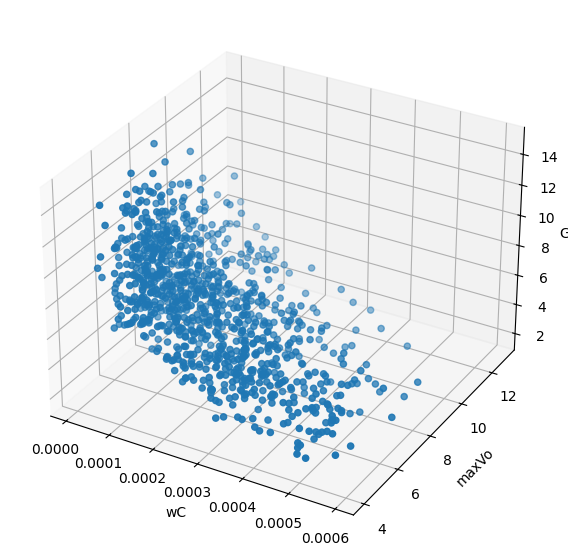

In [18]:
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(data[:,0], data[:,1], data[:,2])
ax.set_xlabel("wC")
ax.set_ylabel("maxVo")
ax.set_zlabel("Gain")
plt.show()

In [5]:
data = np.load(f"./{branch}/data_{n_datapoints}.npy")
avg_maxvo = np.mean(data[:, 3])
print(avg_maxvo)
print(np.max(data[:,3]))
#print(np.mean(data[:, 1]))

for i in range(9):
    print(np.max(data[:,i]))

5.274918485338798
15.21529025641182
9.983846314872599e-09
9977.42560926533
8.2054605484
15.21529025641182
0.49985972344273893
24.81232
1999362.3807278273
19970.388823723642
14.97265199341092


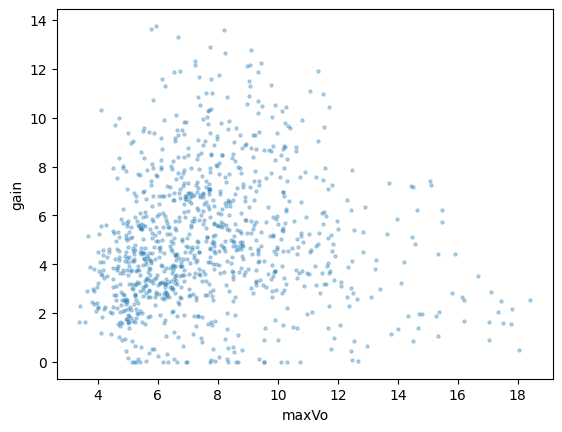

In [2]:
import matplotlib.pyplot as plt
data = np.load(f"./{branch}/data_{n_datapoints}.npy")
maxVo = data[:, 2]
gain = data[:, 3]
plt.scatter(maxVo, gain, alpha=0.3, s=5)
plt.xlabel('maxVo'); plt.ylabel('gain')
plt.savefig('joint_dist.png')

In [ ]:

CL, f, maxVo, gain, Vin, THD, R1, RD, VDD = [data[:, i] for i in range(9)]

#valid = (
#    (gain > 1) &
#    (gain < 100) &
#    (maxVo > 0.1) &
#    (maxVo < 0.9 * VDD) &
#    (THD < 5) &
#    (THD > 0)
#)

valid = (
    (THD < 1)
)


#np.save("./testing/data_valid_1000.npy", data[valid])
print(f"Valid rows: {valid.sum()} / {len(data)} ({100*valid.mean():.1f}%)")
#print(data[np.random.randint(len(data)), :])

Valid rows: 505 / 1000 (50.5%)


In [ ]:
X = data[:, :2]
y = data[:, 2:]

x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_scaled = x_scaler.fit_transform(X)
y_scaled = y_scaler.fit_transform(y)
X_test = x_scaler.transform(np.array([[100e3, 20e-3]]))
print(X_test)

print(x_scaler.data_min_, x_scaler.data_max_)

[[   6701.30740867 2230168.96287325]]
[5.02984184e+00 1.00260675e-09] [1.99515525e+01 9.97053668e-09]


In [ ]:
scaler = joblib.load(f"./{branch}/data_scaler_{n_datapoints}.pkl")
#data = [gain, bandwidth, VDD, Vin, Vto, THD, R1, RD, Kp, CL]
test = np.array([1, 1, 1, 1, 1, 0.5, 1, 1, 1, 1]).reshape(1,-1)
test = np.log10(test)
test_scaled = scaler.transform(test)
print(test_scaled)

# Ideal THD (1%) = -2.35

[[ -3.68537697  -6.30269392  -6.36935768   1.9539196    1.31848404
   -3.13988211 -17.57388372 -17.59969737  13.31747604  33.90159842]]


In [ ]:
data = np.array([1, 1, 6.34, 488.42e-3, 0.5, 1, 132958e3, 309.54e3, 0.0122e-3, 2.3e-9]).reshape(1, -1)
data = np.log10(data)

scaler = joblib.load(f"./{branch}/data_scaler_{n_datapoints}.pkl")
data_scaled = scaler.transform(data)

X_test = np.zeros((1, 7))

X_test[0, :3] = data_scaled[0, 2:5]
X_test[0, 3:] = data_scaled[0, 6:]

model = ResBlockMLP_Predictor(7,3,128)
model.load_state_dict(torch.load(f"{branch}/PerformancePredictor_{n_datapoints}.pth", map_location=torch.device('cpu')))
for param in model.parameters():
    param.requires_grad = False
model.eval()

with torch.no_grad():
    y_pred = model(torch.tensor(X_test, dtype=torch.float32)).cpu().numpy()


temp_arr = np.zeros((1,10))
temp_arr[0,:2] = y_pred[0, :2] # gain, bandwidth
temp_arr[0, 5] = y_pred[0, 2] # THD

temp_arr = scaler.inverse_transform(temp_arr)
y_pred_real = 10**temp_arr[0]

print(y_pred_real)

[5.88167448e+00 1.97956264e+02 1.15471365e+01 2.01024823e-01
 5.60757842e-01 1.76665757e+01 2.02860163e+06 1.97720052e+06
 8.71145319e-05 4.87845052e-09]


In [ ]:
data = np.load(f"./{branch}/data_{n_datapoints}.npy")
cols_to_log = [1,5,6,7]
data[:, cols_to_log] = np.log10(data[:, cols_to_log])
#data = np.log10(data)

scaler = StandardScaler()

data_scaled = scaler.fit_transform(data)
for i in range(10):
    print(max(data_scaled[:,i]))
    print(min(data_scaled[:,i]))

2.5898698116461665
-2.1521812717178825
4.550825236363742
-1.4255560663701572
1.750362649932986
-1.6963926469636241
1.7143405379399779
-1.7381921942372982
1.6652334456996378
-1.7647435278470738
3.6761053100383263
-4.317717543488881
1.0915842406440153
-3.604141373291176
1.123955204597875
-3.619717555955533
1.7294080445267999
-1.7526437328440931
1.7400330533675994
-1.8077189583097102
